# Regression of Used Car Prices

<img src="https://www.kaggle.com/competitions/76728/images/header">

## Dataset Description
The dataset for this competition (both train and test) was generated from a deep learning model trained on the Used Car Price Prediction Dataset. Feature distributions are close to, but not exactly the same, as the original. Feel free to use the original dataset as part of this competition, both to explore differences as well as to see whether incorporating the original in training improves model performance.

*Files*

train.csv - the training dataset; price is the continuous target

test.csv - the test dataset; your objective is to predict the value of price for each row

sample_submission.csv - a sample submission file in the correct format

## Aim & Target 

**Aim**

The primary goal is to develop a regression model to predict the resale price of used cars by analyzing technical specifications and historical data. Following the logic of our previous studies, we aim to transform raw, messy string data into structured features to capture non-linear relationships in a synthetic dataset. Ultimately, we strive to minimize the Root Mean Squared Error (RMSE) to ensure high prediction accuracy.  

**Target**

The target variable is price, representing the continuous numerical value of a vehicle's listing price. Success is measured by the model's ability to handle high-cardinality categorical data and extract signals from complex engine descriptions. The objective is to produce a model that accurately generalizes price trends across diverse brands and configurations.

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

## Reading Dataset & Dataframe Generation

In [2]:
df = pd.read_csv("/kaggle/input/competitions/playground-series-s4e9/train.csv") # We'll work on train data as our dataframe. 

test = pd.read_csv("/kaggle/input/competitions/playground-series-s4e9/test.csv")

In [3]:
df.head()

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,0,MINI,Cooper S Base,2007,213000,Gasoline,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,None reported,Yes,4200
1,1,Lincoln,LS V8,2002,143250,Gasoline,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,At least 1 accident or damage reported,Yes,4999
2,2,Chevrolet,Silverado 2500 LT,2002,136731,E85 Flex Fuel,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,None reported,Yes,13900
3,3,Genesis,G90 5.0 Ultimate,2017,19500,Gasoline,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,45000
4,4,Mercedes-Benz,Metris Base,2021,7388,Gasoline,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,None reported,Yes,97500


## Exploratory Data Analysis & Feature Engineering 

In [4]:
df = df.drop('id', axis=1)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188533 entries, 0 to 188532
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   brand         188533 non-null  object
 1   model         188533 non-null  object
 2   model_year    188533 non-null  int64 
 3   milage        188533 non-null  int64 
 4   fuel_type     183450 non-null  object
 5   engine        188533 non-null  object
 6   transmission  188533 non-null  object
 7   ext_col       188533 non-null  object
 8   int_col       188533 non-null  object
 9   accident      186081 non-null  object
 10  clean_title   167114 non-null  object
 11  price         188533 non-null  int64 
dtypes: int64(3), object(9)
memory usage: 17.3+ MB


In [6]:
df.describe()

,model_year,milage,price
count,188533.000000,188533.000000,1.885330e+05
mean,2015.829998,65705.295174,4.387802e+04
std,5.660967,49798.158076,7.881952e+04
min,1974.000000,100.000000,2.000000e+03
25%,2013.000000,24115.000000,1.700000e+04
50%,2017.000000,57785.000000,3.082500e+04
75%,2020.000000,95400.000000,4.990000e+04
max,2024.000000,405000.000000,2.954083e+06


In [7]:
df.isnull().sum()

brand               0
model               0
model_year          0
milage              0
fuel_type        5083
engine              0
transmission        0
ext_col             0
int_col             0
accident         2452
clean_title     21419
price               0
dtype: int64

In [8]:
df.shape

(188533, 12)

In [9]:
# Data Imputation

df['fuel_type'] = df['fuel_type'].fillna('Other')
df['accident'] = df['accident'].fillna('None reported')
df['clean_title'] = df['clean_title'].fillna('Unknown')

In [10]:
df.isnull().sum()

brand           0
model           0
model_year      0
milage          0
fuel_type       0
engine          0
transmission    0
ext_col         0
int_col         0
accident        0
clean_title     0
price           0
dtype: int64

In [11]:
df.brand.value_counts()

brand
Ford             23088
Mercedes-Benz    19172
BMW              17028
Chevrolet        16335
Audi             10887
Porsche          10612
Land              9525
Toyota            8850
Lexus             8643
Jeep              6474
Cadillac          4674
RAM               4249
Nissan            3930
Tesla             3738
INFINITI          3276
GMC               3215
Dodge             3133
Mazda             2719
Kia               2497
Lincoln           2423
Subaru            2381
Acura             2282
Honda             2101
Hyundai           2045
Volkswagen        1765
Jaguar            1319
Bentley           1155
MINI              1064
Genesis            969
Buick              940
Maserati           939
Lamborghini        809
Chrysler           727
Volvo              723
Alfa               682
Rivian             590
Rolls-Royce        561
Mitsubishi         551
Pontiac            538
Hummer             520
Ferrari            359
McLaren            243
Aston              238
Satur

In [12]:
df.model.value_counts()

model
F-150 XLT                        2945
M3 Base                          2229
Camaro 2SS                       1709
M4 Base                          1622
Mustang GT Premium               1526
                                 ... 
ForTwo Pure                         2
X5 3.0i                             1
X5 xDrive40e                        1
XLR Base                            1
Integra w/A-Spec Tech Package       1
Name: count, Length: 1897, dtype: int64

In [13]:
df.model_year.value_counts()

model_year
2021    18198
2018    16414
2020    15848
2022    15749
2019    15409
2016    13696
2017    12794
2015    11389
2023     8769
2014     8415
2013     6796
2011     6265
2012     6095
2008     5156
2007     4876
2010     4235
2005     3129
2006     2814
2009     2716
2004     2570
2003     1906
2001     1534
2002     1282
2000      558
1999      554
1998      343
1997      312
1996      189
2024      162
1993      140
1995      102
1994       92
1992       14
1974       12
Name: count, dtype: int64

In [14]:
# Create 'age' feature
# We use 2024 as the reference year since the data includes 2024 models
df['car_age'] = 2024 - df['model_year']

# Now we can drop 'model_year' to avoid redundancy, matching your 'Step 4' logic
df.drop('model_year', axis=1, inplace=True)

In [15]:
df.milage.value_counts()

milage
60000     1319
170000    1246
120000    1178
110000    1155
130000     970
          ... 
30598        1
4150         1
16758        1
72429        1
26545        1
Name: count, Length: 6651, dtype: int64

In [16]:
df.milage.unique()

array([213000, 143250, 136731, ...,   4721,   2922, 134603])

In [17]:
# Converting Objects to Numeric
df['milage'] = df['milage'].astype(str).str.replace(',', '').str.replace(' mi.', '', regex=False).astype(float)

In [18]:
df.fuel_type.value_counts()

fuel_type
Gasoline          165940
Hybrid              6832
E85 Flex Fuel       5406
Other               5083
Diesel              3955
–                    781
Plug-In Hybrid       521
not supported         15
Name: count, dtype: int64

In [19]:
# Clean up noisy fuel types before encoding, following class note logic
# We map '–' and 'not supported' to 'Other'
df['fuel_type'] = df['fuel_type'].replace(['–', 'not supported'], 'Other')

# Re-verify the counts to ensure it's clean
print(df['fuel_type'].value_counts())

fuel_type
Gasoline          165940
Hybrid              6832
Other               5879
E85 Flex Fuel       5406
Diesel              3955
Plug-In Hybrid       521
Name: count, dtype: int64


In [20]:
df.engine.value_counts()

engine
355.0HP 5.3L 8 Cylinder Engine Gasoline Fuel           3462
240.0HP 2.0L 4 Cylinder Engine Gasoline Fuel           2902
420.0HP 6.2L 8 Cylinder Engine Gasoline Fuel           2841
2.0L I4 16V GDI DOHC Turbo                             2680
375.0HP 3.5L V6 Cylinder Engine Gasoline Fuel          2451
                                                       ... 
151.0HP 1.5L 4 Cylinder Engine Gas/Electric Hybrid        1
184.0HP 2.4L 4 Cylinder Engine Flex Fuel Capability       1
78.0HP 1.2L 3 Cylinder Engine Gasoline Fuel               1
139.0HP 1.6L 4 Cylinder Engine Plug-In Electric/Gas       1
313.0HP 2.0L 4 Cylinder Engine Plug-In Electric/Gas       1
Name: count, Length: 1117, dtype: int64

In [21]:
df.engine.unique()

array(['172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel',
       '252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel',
       '320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capability', ...,
       '78.0HP 1.2L 3 Cylinder Engine Gasoline Fuel',
       '139.0HP 1.6L 4 Cylinder Engine Plug-In Electric/Gas',
       '313.0HP 2.0L 4 Cylinder Engine Plug-In Electric/Gas'],
      dtype=object)

In [22]:
import re

# 1. Detailed Extraction Functions
def extract_engine_features(engine_str):
    engine_str = str(engine_str)
    
    # Extract Horsepower (e.g., 355.0HP)
    hp = re.search(r'(\d+\.?\d*)HP', engine_str)
    
    # Extract Liters (e.g., 5.3L)
    liter = re.search(r'(\d+\.?\d*)L', engine_str)
    
    # Extract Cylinder Count (e.g., 8 Cylinder or V6)
    # This regex looks for '8 Cylinder', 'V6', or 'I4'
    cyl = re.search(r'(\d+)\s*Cylinder|[VvIi](\d+)', engine_str)
    
    # Extract Valve Count (e.g., 16V)
    valves = re.search(r'(\d+)\s*[Vv](?!\d)', engine_str)
    
    # Binary: Is it Turbo/Supercharged?
    is_forced = 1 if any(x in engine_str.upper() for x in ['TURBO', 'SUPERCHARGED', 'TC']) else 0
    
    # Extract Cylinder result logic
    cyl_val = np.nan
    if cyl:
        cyl_val = float(cyl.group(1)) if cyl.group(1) else float(cyl.group(2))

    return pd.Series([
        float(hp.group(1)) if hp else np.nan,
        float(liter.group(1)) if liter else np.nan,
        cyl_val,
        float(valves.group(1)) if valves else np.nan,
        is_forced
    ])

# 2. Applying the extraction to create new columns
df[['horsepower', 'engine_liter', 'cylinders', 'valves', 'is_forced_induction']] = df['engine'].apply(extract_engine_features)

# 3. Targeted Imputation (Class Note Style)
# For engine specs, we use median to avoid outlier skewing
for col in ['horsepower', 'engine_liter', 'cylinders', 'valves']:
    df[col] = df[col].fillna(df[col].median())

# 4. Drop the original messy column
df.drop('engine', axis=1, inplace=True)

In [23]:
df.transmission.value_counts()

transmission
A/T                                                   49904
8-Speed A/T                                           20645
Transmission w/Dual Shift Mode                        19255
6-Speed A/T                                           18044
6-Speed M/T                                           11998
7-Speed A/T                                           11124
Automatic                                             10691
8-Speed Automatic                                      8431
10-Speed A/T                                           8044
9-Speed A/T                                            3866
5-Speed A/T                                            3217
10-Speed Automatic                                     3164
6-Speed Automatic                                      2799
4-Speed A/T                                            2546
5-Speed M/T                                            2409
9-Speed Automatic                                      2325
CVT Transmission           

In [24]:
# Transmission Feature Engineering 

import re

def clean_transmission_advanced(trans_str):
    trans_str = str(trans_str).upper()
    
    # 1. Extract Number of Speeds (e.g., '8-Speed', '10-Speed', '6')
    # We look for a number followed by 'SPEED' or just a lone number at the start
    speed_match = re.search(r'(\d+)-?SPEED|(\d+)\s', trans_str)
    speeds = float(speed_match.group(1) or speed_match.group(2)) if speed_match else np.nan
    
    # 2. Identify the Technology Type
    if any(x in trans_str for x in ['M/T', 'MANUAL']):
        t_type = 'Manual'
    elif any(x in trans_str for x in ['CVT', 'VARIABLE']):
        t_type = 'CVT'
    elif any(x in trans_str for x in ['DUAL SHIFT', 'DCT', 'AUTO-SHIFT']):
        t_type = 'Dual-Clutch/Semi-Auto'
    elif any(x in trans_str for x in ['A/T', 'AUTOMATIC', '1-SPEED']):
        t_type = 'Automatic'
    else:
        t_type = 'Other' # Handles 'F', '2', '–', and production noise
        
    return pd.Series([speeds, t_type])

# Apply the function
df[['trans_speeds', 'trans_type']] = df['transmission'].apply(clean_transmission_advanced)

# Targeted Imputation (Matching your Laptop logic)
df['trans_speeds'] = df['trans_speeds'].fillna(df['trans_speeds'].median())

# Drop the original column
df.drop('transmission', axis=1, inplace=True)

In [25]:
df.ext_col.value_counts()

ext_col
Black                                 48658
White                                 43815
Gray                                  25293
Silver                                16995
Blue                                  14555
                                      ...  
Granite Crystal Metallic Clearcoat        5
GT SILVER                                 5
Blue Caelum                               5
BLUE                                      3
Mango Tango Pearlcoat                     2
Name: count, Length: 319, dtype: int64

In [26]:
def clean_color(color_str):
    c = str(color_str).upper()
    
    # 1. Capture the 'Finish' (Feature Engineering)
    # Metallic and Pearl paints usually cost more
    is_premium_paint = 1 if any(x in c for x in ['METALLIC', 'PEARL', 'COAT', 'MATTE']) else 0
    
    # 2. Map to Master Colors (The "Cleanest" way to group 319 values)
    if 'BLACK' in c: master = 'Black'
    elif 'WHITE' in c: master = 'White'
    elif 'SILVER' in c or 'GRAY' in c or 'GREY' in c or 'GRANITE' in c: master = 'Silver/Gray'
    elif 'BLUE' in c: master = 'Blue'
    elif 'RED' in c: master = 'Red'
    elif 'BROWN' in c or 'BEIGE' in c or 'TAN' in c: master = 'Brown/Beige'
    elif 'GREEN' in c: master = 'Green'
    elif 'ORANGE' in c or 'MANGO' in c: master = 'Orange'
    elif 'YELLOW' in c or 'GOLD' in c: master = 'Yellow/Gold'
    else: master = 'Other'
    
    return pd.Series([master, is_premium_paint])

# Apply to External Color
df[['ext_color_clean', 'is_premium_paint']] = df['ext_col'].apply(clean_color)

# Drop original messy column
df.drop(['ext_col'], axis=1, inplace=True)

In [27]:
df.int_col.value_counts()

int_col
Black           107674
Beige            24495
Gray             21204
Brown             5810
Red               5145
                 ...  
Bianco Polar         7
Classic Red          7
Cobalt Blue          6
WHITE                6
ORANGE               4
Name: count, Length: 156, dtype: int64

In [28]:
def clean_interior_color(color_str):
    c = str(color_str).upper()
    
    # Mapping the 156 messy strings into 7 clean categories
    if any(x in c for x in ['BLACK', 'EBONY', 'CHARCOAL', 'JET']): return 'Black'
    if any(x in c for x in ['GRAY', 'GREY', 'SILVER']): return 'Gray'
    if any(x in c for x in ['BEIGE', 'TAN', 'CREAM', 'IVORY', 'CANBERRA']): return 'Beige'
    if any(x in c for x in ['BROWN', 'COGNAC', 'SADDLE', 'MOCHA']): return 'Brown'
    if any(x in c for x in ['RED', 'ADRENALINE', 'ROSSO']): return 'Red'
    if any(x in c for x in ['WHITE', 'BIANCO']): return 'White'
    if 'BLUE' in c: return 'Blue'
    
    return 'Other'

# Apply the mapping
df['int_color_clean'] = df['int_col'].apply(clean_interior_color)

df.drop(['int_col'], axis=1, inplace=True)

In [29]:
df.accident.value_counts()

accident
None reported                             146966
At least 1 accident or damage reported     41567
Name: count, dtype: int64

In [30]:
# 1. Create a binary map for the two categories
accident_map = {
    'None reported': 0,
    'At least 1 accident or damage reported': 1
}

# 2. Apply the mapping to create a clean numeric feature
df['has_accident'] = df['accident'].map(accident_map)

# 3. Handle any rare nulls by assuming 'None reported' (0), following class notes
df['has_accident'] = df['has_accident'].fillna(0).astype(int)

# 4. Drop the original string column
df.drop('accident', axis=1, inplace=True)

In [31]:
df.clean_title.value_counts()

clean_title
Yes        167114
Unknown     21419
Name: count, dtype: int64

In [32]:
# 1. Binary Mapping
# 'Yes' becomes 1, 'Unknown' becomes 0
df['is_clean_title'] = df['clean_title'].apply(lambda x: 1 if x == 'Yes' else 0)

# 2. Drop the original column
df.drop('clean_title', axis=1, inplace=True)

In [33]:
df.price.value_counts()

price
15000     1920
12000     1459
30000     1280
29000     1228
8500      1204
          ... 
239991      22
269991      22
259991      21
107998      20
45998       19
Name: count, Length: 1569, dtype: int64

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188533 entries, 0 to 188532
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   brand                188533 non-null  object 
 1   model                188533 non-null  object 
 2   milage               188533 non-null  float64
 3   fuel_type            188533 non-null  object 
 4   price                188533 non-null  int64  
 5   car_age              188533 non-null  int64  
 6   horsepower           188533 non-null  float64
 7   engine_liter         188533 non-null  float64
 8   cylinders            188533 non-null  float64
 9   valves               188533 non-null  float64
 10  is_forced_induction  188533 non-null  float64
 11  trans_speeds         188533 non-null  float64
 12  trans_type           188533 non-null  object 
 13  ext_color_clean      188533 non-null  object 
 14  is_premium_paint     188533 non-null  int64  
 15  int_color_clean  

In [35]:
df.head()

,brand,model,milage,fuel_type,price,car_age,horsepower,engine_liter,cylinders,valves,is_forced_induction,trans_speeds,trans_type,ext_color_clean,is_premium_paint,int_color_clean,has_accident,is_clean_title
0,MINI,Cooper S Base,213000.0,Gasoline,4200,17,172.0,1.6,4.0,24.0,0.0,7.0,Automatic,Yellow/Gold,0,Gray,0,1
1,Lincoln,LS V8,143250.0,Gasoline,4999,22,252.0,3.9,8.0,24.0,0.0,7.0,Automatic,Silver/Gray,0,Beige,1,1
2,Chevrolet,Silverado 2500 LT,136731.0,E85 Flex Fuel,13900,22,320.0,5.3,8.0,24.0,0.0,7.0,Automatic,Blue,0,Gray,0,1
3,Genesis,G90 5.0 Ultimate,19500.0,Gasoline,45000,7,420.0,5.0,8.0,24.0,0.0,7.0,Dual-Clutch/Semi-Auto,Black,0,Black,0,1
4,Mercedes-Benz,Metris Base,7388.0,Gasoline,97500,3,208.0,2.0,4.0,24.0,0.0,7.0,Automatic,Black,0,Beige,0,1


In [36]:
abs(df.corr(numeric_only=True)['price']).sort_values(ascending=False)

price                  1.000000
milage                 0.283067
car_age                0.231795
horsepower             0.207837
cylinders              0.129834
has_accident           0.125122
trans_speeds           0.103788
is_forced_induction    0.097981
engine_liter           0.091372
is_clean_title         0.089433
is_premium_paint       0.049393
valves                 0.047085
Name: price, dtype: float64

## Model Development

In [37]:
# One-hot encoding 

# We drop 'model' to avoid high cardinality, exactly like dropping specific IDs
cols_to_encode = ['brand', 'fuel_type', 'trans_type', 'ext_color_clean', 'int_color_clean']
df_final = pd.get_dummies(df.drop('model', axis=1), columns=cols_to_encode, drop_first=True)

In [38]:
x = df_final.drop('price', axis=1)
y = df_final['price']

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor, RadiusNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree, ExtraTreeRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler

def algo_test(x, y):
    # Initialize all models
    L = LinearRegression()
    R = Ridge()
    Lass = Lasso()
    E = ElasticNet()
    sgd = SGDRegressor()
    ETR = ExtraTreeRegressor()
    GBR = GradientBoostingRegressor()
    kn = KNeighborsRegressor()
    # RadiusNeighbors is initialized but not included in the primary list to match your original flow
    rkn = RadiusNeighborsRegressor(radius=1.0)
    ada = AdaBoostRegressor()
    dt = DecisionTreeRegressor()
    xgb = XGBRegressor()
    
    algos = [L, R, Lass, E, sgd, ETR, GBR, ada, kn, dt, xgb]
    algo_names = ['Linear', 'Ridge', 'Lasso', 'ElasticNet', 'SGD', 'Extra Tree', 
              'Gradient Boosting', 'AdaBoost', 'KNeighborsRegressor', 
              'Decision Tree', 'XGBRegressor']
    
    # Scale features and split data
    x = MinMaxScaler().fit_transform(x)
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

    r_squared = []
    rmse = []
    mae = []

    # Create a dataframe to store error and accuracy metrics
    result = pd.DataFrame(columns=['R_Squared', 'RMSE', 'MAE'], index=algo_names)

    # Loop through models to train and predict
    for algo in algos:
        p = algo.fit(x_train, y_train).predict(x_test)
        r_squared.append(r2_score(y_test, p))
        rmse.append(mean_squared_error(y_test, p)**.5)
        mae.append(mean_absolute_error(y_test, p))

    # Populate the result table with calculated metrics
    result.R_Squared = r_squared
    result.RMSE = rmse
    result.MAE = mae

    # Sort the table by accuracy (R-Squared) and return it
    result_table = result.sort_values('R_Squared', ascending=False)
    return result_table

In [40]:
x=pd.get_dummies(x,drop_first=True)

In [41]:
result= algo_test(x,y)

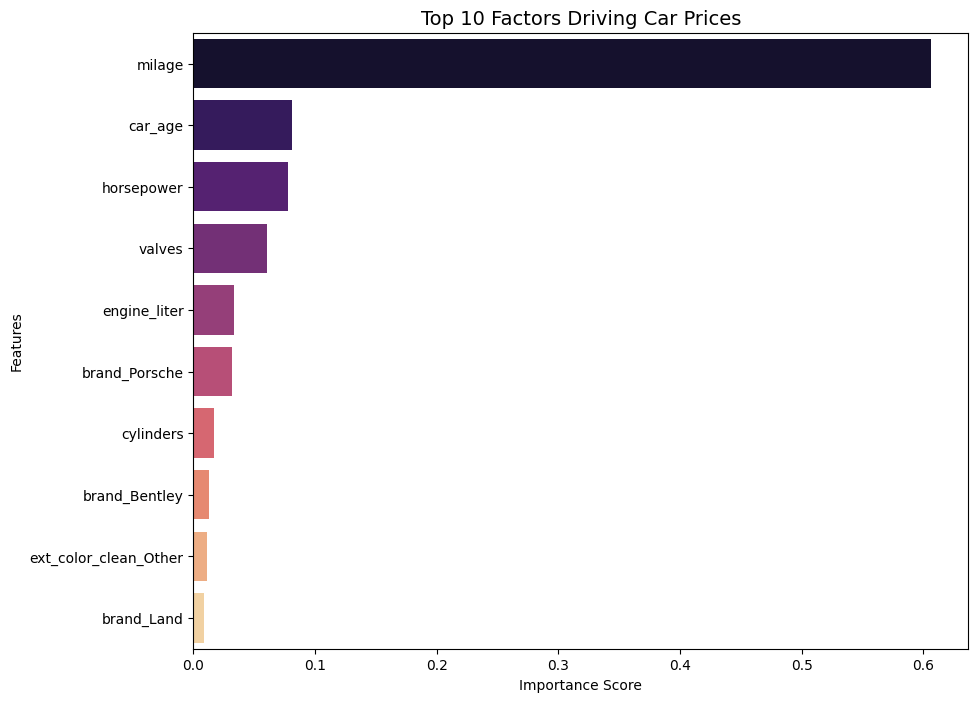

In [42]:
# Re-fitting Gradient Boosting to get feature importances
from sklearn.ensemble import GradientBoostingRegressor

# Use the x and y we prepared for the algo_test
gbr_model = GradientBoostingRegressor(random_state=42)
gbr_model.fit(x, y)

# Get feature importance
importances = gbr_model.feature_importances_
feature_names = x.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(10)

# Plotting
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma')
plt.title('Top 10 Factors Driving Car Prices', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

In [43]:
import joblib
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import MinMaxScaler

# 1. Initialize a FRESH model instance (since GBR was local to the function)
final_gbr = GradientBoostingRegressor(random_state=42) 

# 2. Fit the model on your data
# This is where the actual "learning" happens for the final file
final_gbr.fit(x, y)

# 3. Save the Gradient Boosting model
joblib.dump(final_gbr, 'car_price_model.pkl')

# 4. Save the MinMaxScaler 
# Your Streamlit app needs this to scale user inputs (like mileage) exactly like the training data
scaler = MinMaxScaler().fit(x)
joblib.dump(scaler, 'scaler.pkl')

# 5. Save the Feature Names
# This ensures your app uses the same column order (very important for dummy variables!)
feature_names = x.columns.tolist()
joblib.dump(feature_names, 'features.pkl')

print("Files saved successfully! You can now find car_price_model.pkl, scaler.pkl, and features.pkl in your Kaggle output folder.")

Files saved successfully! You can now find car_price_model.pkl, scaler.pkl, and features.pkl in your Kaggle output folder.


In [44]:
from IPython.display import FileLink

display(FileLink('car_price_model.pkl'))
display(FileLink('scaler.pkl'))
display(FileLink('features.pkl'))

/kaggle/working/car_price_model.pkl

/kaggle/working/scaler.pkl

/kaggle/working/features.pkl

## Kaggle Competition Submission

In [45]:
def clean_data(df):
    df_copy = df.copy()
    # Insert your regex for engine/horsepower here
    # Insert your color mapping here
    # Insert your transmission cleaning here
    # Example: df_copy['milage'] = df_copy['milage'].fillna(0) 
    return df_copy

# Now run your submission code again
test_processed = clean_data(test)

In [46]:
# 1. Isolate IDs for the final file
test_ids = test['id']

# 2. Apply your cleaning function to the test data
# This ensures horsepower, transmission, and color columns are processed
test_processed = clean_data(test)

# 3. Handle Encoding to match your training features (x)
# Drop 'model' like we did in Block 37 and create dummies
test_encoded = pd.get_dummies(test_processed.drop(['model', 'id'], axis=1), drop_first=True)

# 4. Critical Step: Align test columns with training columns
# This adds missing dummy columns as 0s and removes extras
test_encoded = test_encoded.reindex(columns=x.columns, fill_value=0)

# 5. Scaling (using the scaler from your algo_test logic)
test_scaled = MinMaxScaler().fit(x).transform(test_encoded)

# 6. Predict using the Gradient Boosting model
final_predictions = gbr_model.predict(test_scaled)

# 7. Create and Save the CSV
submission = pd.DataFrame({'id': test_ids, 'price': final_predictions})
submission.to_csv('submission.csv', index=False)

print("Graphs generated and submission.csv is ready for download!")

Graphs generated and submission.csv is ready for download!


In [47]:
from IPython.display import FileLink

display(FileLink('submission.csv'))

/kaggle/working/submission.csv

## Hugging Face Link

https://huggingface.co/spaces/basaktamer/Used_Car_Prices